In [2]:

import os

os.environ['HF_ENDPOINT'] = 'https://hf-mirror.com'

from sentence_transformers import SentenceTransformer
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'serif'

/home/wangtao/src/kg4rd/.venv/lib/python3.11/site-packages/torch/cuda/__init__.py:51: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [3]:
disease_nodes = pd.read_csv('../kg/nodes.csv', low_memory=False).query('node_type == "disease"')
disease_nodes.shape[0]

28063

In [4]:
diease_def = pd.read_csv('../../../data/data_feature/disease_mondo.csv', low_memory=False)
diease_def['mondo_id'] = diease_def['mondo_id'].apply(lambda x: 'kg4rd:' + str(x))

diease_desc = pd.read_csv('../../../data/data_feature/disease_umls.csv', low_memory=False)
diease_desc['mondo_id'] = diease_desc['mondo_id'].apply(lambda x: 'kg4rd:' + str(x))

diseases = pd.DataFrame(pd.merge(disease_nodes, diease_def, left_on='node_id', right_on='mondo_id', how='left')[[
    'node_index', 'node_id', 'node_type', 'node_name', 'node_source', 'definition'
]])
diseases = pd.DataFrame(pd.merge(diseases, diease_desc, left_on='node_id', right_on='mondo_id', how='left')[[
    'node_index', 'node_id', 'node_type', 'node_name', 'node_source', 'definition', 'description'
]])

diseases.tail()

,node_index,node_id,node_type,node_name,node_source,definition,description
28058,94378,kg4rd:8851,disease,obsolete autism,MONDO,NaN,NaN
28059,94379,kg4rd:8940,disease,obsolete endosteal sclerosis-cerebellar hypopl...,MONDO,NaN,NaN
28060,94380,kg4rd:8996,disease,obsolete COACH syndrome 1,MONDO,OBSOLETE. A very rare subtype of Joubert syndr...,NaN
28061,94381,kg4rd:9325,disease,obsolete deafness-enamel hypoplasia-nail defec...,MONDO,NaN,NaN
28062,94382,kg4rd:9829,disease,"obsolete pallidal degeneration, progressive, w...",MONDO,NaN,NaN


In [5]:
print("总疾病数量:", diseases.shape[0])
print("\n同时有定义和描述:", (diseases['definition'].notna() & diseases['description'].notna()).sum())
print("只有定义:", (diseases['definition'].notna() & diseases['description'].isna()).sum())
print("只有描述:", (diseases['definition'].isna() & diseases['description'].notna()).sum())
print("都没有:", (diseases['definition'].isna() & diseases['description'].isna()).sum())
print("\n有定义或描述的总数:", (diseases['definition'].notna() | diseases['description'].notna()).sum())

总疾病数量: 28063

同时有定义和描述: 12237
只有定义: 5950
只有描述: 1725
都没有: 8151

有定义或描述的总数: 19912


In [6]:
def prepare_disease_texts(diseases: pd.DataFrame):
    diseases_for_clustering = diseases[diseases['definition'].notna() | diseases['description'].notna()].copy().reset_index(drop=True)  # 19912
    
    def combine_texts(row):
        texts = []
        if pd.notna(row['node_name']):
            texts.append(f"Disease Name: {row['node_name']}")
        if pd.notna(row['definition']):
            texts.append(f"Definition: {row['definition']}")
        if pd.notna(row['description']):
            texts.append(f"Description: {row['description']}")
        return " | ".join(texts)
    
    diseases_for_clustering['combined_text'] = diseases_for_clustering.apply(combine_texts, axis=1)
    return diseases_for_clustering

diseases_for_clustering = prepare_disease_texts(diseases)
diseases_for_clustering.tail()

,node_index,node_id,node_type,node_name,node_source,definition,description,combined_text
19907,94287,kg4rd:21034,disease,obsolete hereditary alopecia,MONDO,OBSOLETE. An instance of alopecia that is caus...,NaN,Disease Name: obsolete hereditary alopecia | D...
19908,94303,kg4rd:24624,disease,obsolete atrophy of lacrimal gland,MONDO,OBSOLETE. A degenerative disorder that involve...,NaN,Disease Name: obsolete atrophy of lacrimal gla...
19909,94305,kg4rd:25481,disease,obsolete zoonosis,MONDO,OBSOLETE. An infectious disease of non-human a...,Diseases of non-human animals that may be tran...,Disease Name: obsolete zoonosis | Definition: ...
19910,94328,kg4rd:3804,disease,obsolete blood protein disease,MONDO,NaN,Hematologic diseases caused by structural or f...,Disease Name: obsolete blood protein disease |...
19911,94380,kg4rd:8996,disease,obsolete COACH syndrome 1,MONDO,OBSOLETE. A very rare subtype of Joubert syndr...,NaN,Disease Name: obsolete COACH syndrome 1 | Defi...


In [7]:
def generate_embeddings(texts, model_name='neuml/pubmedbert-base-embeddings'):
    model = SentenceTransformer(model_name, device='cuda:1')
    embeddings = model.encode(
        texts, 
        show_progress_bar=True, 
        device='cuda:1',
        batch_size=64,
        convert_to_numpy=True
    )
    return embeddings

embeddings = generate_embeddings(diseases_for_clustering['combined_text'].tolist())
embeddings.shape

Batches:   0%|          | 0/312 [00:00<?, ?it/s]

(19912, 768)

In [8]:
similarity_matrix = cosine_similarity(embeddings)
similarity_matrix.shape

(19912, 19912)

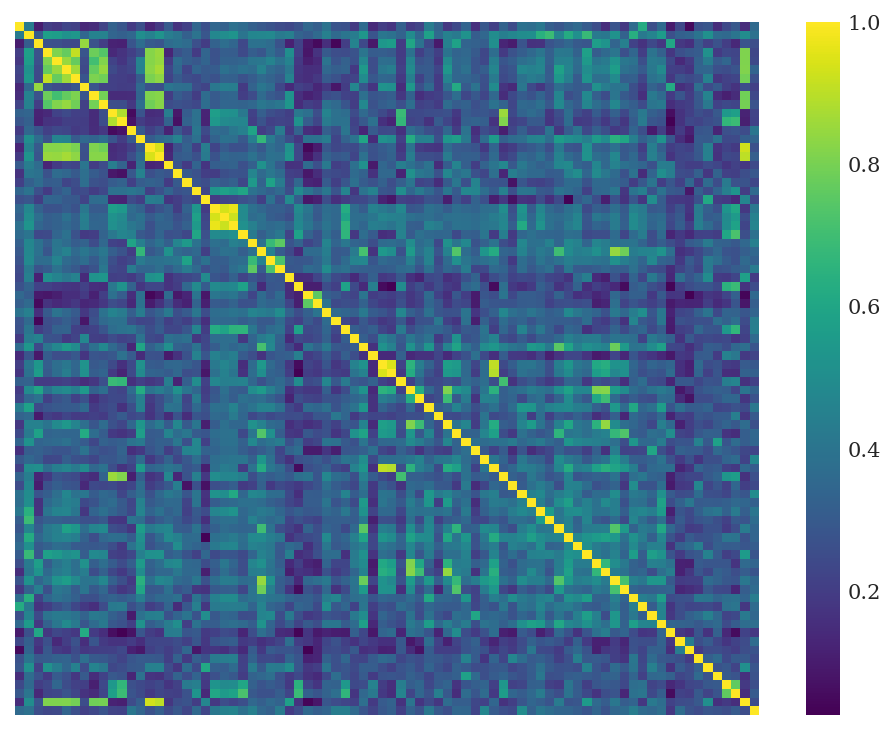

In [9]:
plt.figure(figsize=(8, 6))
sns.heatmap(similarity_matrix[:80, :80], cmap='viridis', fmt='.2f', xticklabels=False, yticklabels=False)
plt.show()

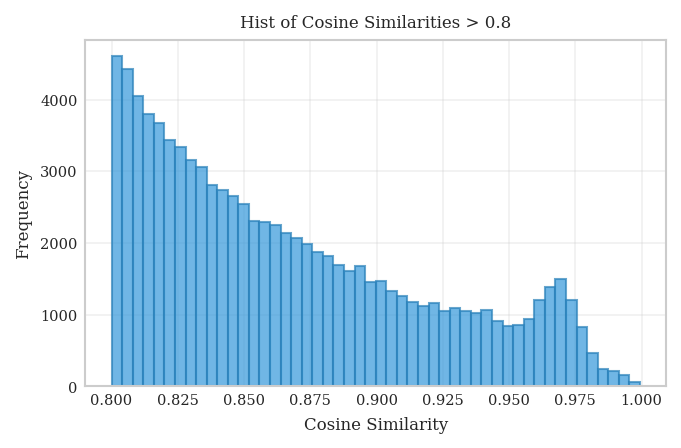

In [10]:
half_similarity = similarity_matrix[ np.triu_indices_from(similarity_matrix, k=1) ]  # 上三角矩阵（不包含对角线）
high_similarity = half_similarity[half_similarity > 0.8]

# 绘制直方图
plt.figure(figsize=(5, 3))
plt.hist(high_similarity, bins=50, alpha=0.7, color='#3498db', edgecolor='#2980b9', linewidth=1)
plt.title('Hist of Cosine Similarities > 0.8', fontsize=8)
plt.xlabel('Cosine Similarity', fontsize=8)
plt.ylabel('Frequency', fontsize=8)
plt.tick_params(axis='both', labelsize=7)  # 坐标轴字体调小
plt.grid(True, alpha=0.3)
plt.show()

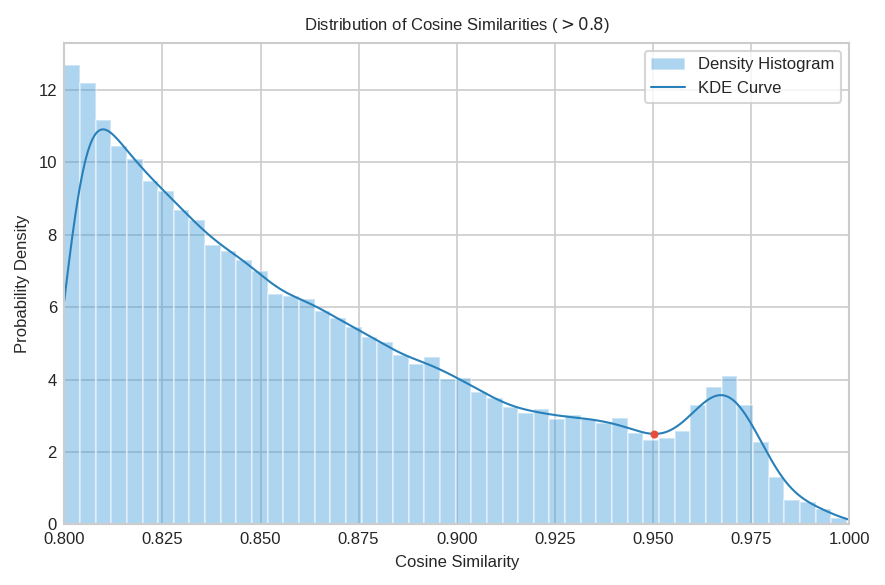

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy.signal import argrelextrema

plt.style.use('seaborn-v0_8-whitegrid')

half_similarity = similarity_matrix[np.triu_indices_from(similarity_matrix, k=1)]
high_similarity = half_similarity[half_similarity > 0.8]

kde = gaussian_kde(high_similarity)
x_plot = np.linspace(0.8, 1.0, 1000)
y_plot = kde(x_plot)

min_indices = argrelextrema(y_plot, np.less)[0]
min_x = x_plot[min_indices]
min_y = y_plot[min_indices]

fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(high_similarity, bins=50, density=True, alpha=0.4, 
        color='#3498db', edgecolor='white', label='Density Histogram')

ax.plot(x_plot, y_plot, color='#2980b9', lw=1, label='KDE Curve')

for x, y in zip(min_x, min_y):
    ax.scatter(x, y, color='#e74c3c', s=8, zorder=5)
    # ax.annotate(f'Min: {x:.3f}', xy=(x, y), xytext=(x, y + 0.5),
    #             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
    #             fontsize=9, ha='center', fontweight='bold')

ax.set_title('Distribution of Cosine Similarities ($> 0.8$)', fontsize=8)
ax.set_xlabel('Cosine Similarity', fontsize=8)
ax.set_ylabel('Probability Density', fontsize=8)
ax.set_xlim(0.8, 1.0)
ax.tick_params(axis='both', labelsize=8)
ax.legend(frameon=True, fontsize=8)

plt.tight_layout()
plt.savefig('similarity_distribution.pdf', bbox_inches='tight')
plt.show()

In [18]:
# 选定相似度阈值为 0.950

clustering = AgglomerativeClustering(
    n_clusters=None,  # pyright: ignore[reportArgumentType]
    metric='precomputed',
    linkage='complete',
    memory='/tmp/cache',
    distance_threshold=0.05 # 距离阈值 大于此距离则不进行聚类 也就是只关注相似度 >0.95 的 disease
)
labels = clustering.fit_predict(1-similarity_matrix)  #1- similarity_matrix 转为距离矩阵
labels.shape

(19912,)

In [21]:
import numpy as np
import pandas as pd

# 计算每个簇内的实体数
label_counts = pd.Series(labels).value_counts()

# 计算统计量
total_clusters = len(label_counts)
mean_cluster_size = label_counts.mean()
std_cluster_size = label_counts.std()
quantiles = label_counts.quantile([0.25, 0.5, 0.75])
max_cluster_size = label_counts.max()

print(f'总簇数: {total_clusters}')
print(f'均值: {mean_cluster_size:.2f}')
print(f'标准差: {std_cluster_size:.2f}')
print(f'第一四分位数(Q1): {quantiles[0.25]:.0f}')
print(f'中位数(Q2): {quantiles[0.5]:.0f}')
print(f'第三四分位数(Q3): {quantiles[0.75]:.0f}')
print(f'最大簇内实体数: {max_cluster_size}')


总簇数: 17989
均值: 1.11
标准差: 0.75
第一四分位数(Q1): 1
中位数(Q2): 1
第三四分位数(Q3): 1
最大簇内实体数: 40


In [19]:
print('聚类后疾病类别数: ', len(set(labels)))

聚类后疾病类别数:  17989


In [ ]:
diseases_for_clustering['label'] = labels

diseases_for_clustering.head()

,node_index,node_id,node_type,node_name,node_source,definition,description,combined_text,label
0,32370,kg4rd:16045,disease,tetragametic chimerism,MONDO,"Tetragametic chimerism is a rare, sex chromoso...","A rare, sex chromosome disorder of sex develop...",Disease Name: tetragametic chimerism | Definit...,14099
1,32371,kg4rd:8959,disease,CHAND syndrome,MONDO,NaN,A rare ectodermal dysplasia syndrome character...,Disease Name: CHAND syndrome | Description: A ...,10998
2,32372,kg4rd:16562,disease,progressive supranuclear palsy-pure akinesia w...,MONDO,PSP-Pure akinesia with gait freezing (PSP-PAGF...,An atypical variant of progressive supranuclea...,Disease Name: progressive supranuclear palsy-p...,15004
3,32373,kg4rd:19308,disease,junctional epidermolysis bullosa inversa,MONDO,Junctional epidermolysis bullosa inversa is a ...,A rare intermediate form of junctional epiderm...,Disease Name: junctional epidermolysis bullosa...,16133
4,32374,kg4rd:19309,disease,late-onset junctional epidermolysis bullosa,MONDO,Late-onset junctional epidermolysis bullosa is...,A subtype of junctional epidermolysis bullosa ...,Disease Name: late-onset junctional epidermoly...,11554
